In [2]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import Lasso
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

[27.82809103] -2.29474455867698


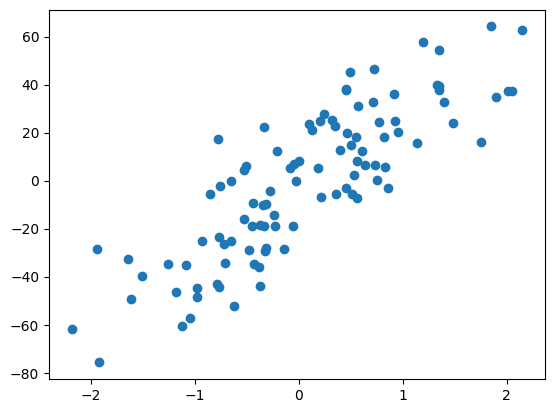

In [3]:
x, y = make_regression(n_samples = 100, n_features = 1, n_informative = 1, n_targets= 1, noise = 20, random_state = 13)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 13)

plt.scatter(x, y)

lr = LinearRegression()
lr.fit(x, y)
print(lr.coef_, lr.intercept_)

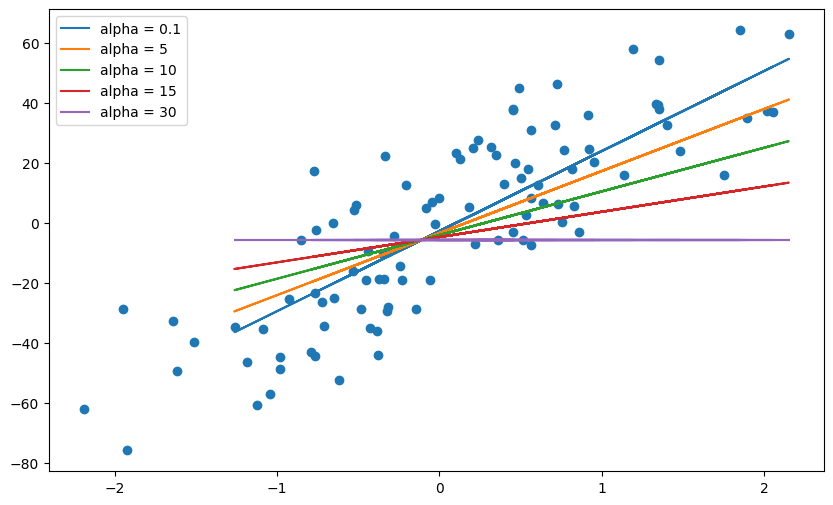

In [7]:
alpha = [0.1, 5, 10, 15, 30]
plt.figure(figsize = (10, 6))
plt.scatter(x, y)
for i in alpha:
    lasso = Lasso(alpha = i)
    lasso.fit(x_train, y_train)
    plt.plot(x_test, lasso.predict(x_test), label = 'alpha = ' + str(i))
plt.legend()
plt.show()

In [8]:
from sklearn.metrics import r2_score

# **how coeffs are affected**

In [15]:
from sklearn.datasets import load_diabetes
data = load_diabetes()
df = pd.DataFrame(data.data, columns = data.feature_names)
df['target'] = data.target
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [18]:
x_train, x_test, y_train, y_test = train_test_split(data.data, data.target, test_size = 0.2, random_state = 13)

In [19]:
coef = []
r2_scores = []

for i in [0, .1, 1, 10]:
    lasso = Lasso(alpha = i)
    lasso.fit(x_train, y_train)

    coef.append(lasso.coef_.tolist())
    y_pred = lasso.predict(x_test)
    r2_scores.append(r2_score(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.986e+05, tolerance: 2.184e+02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

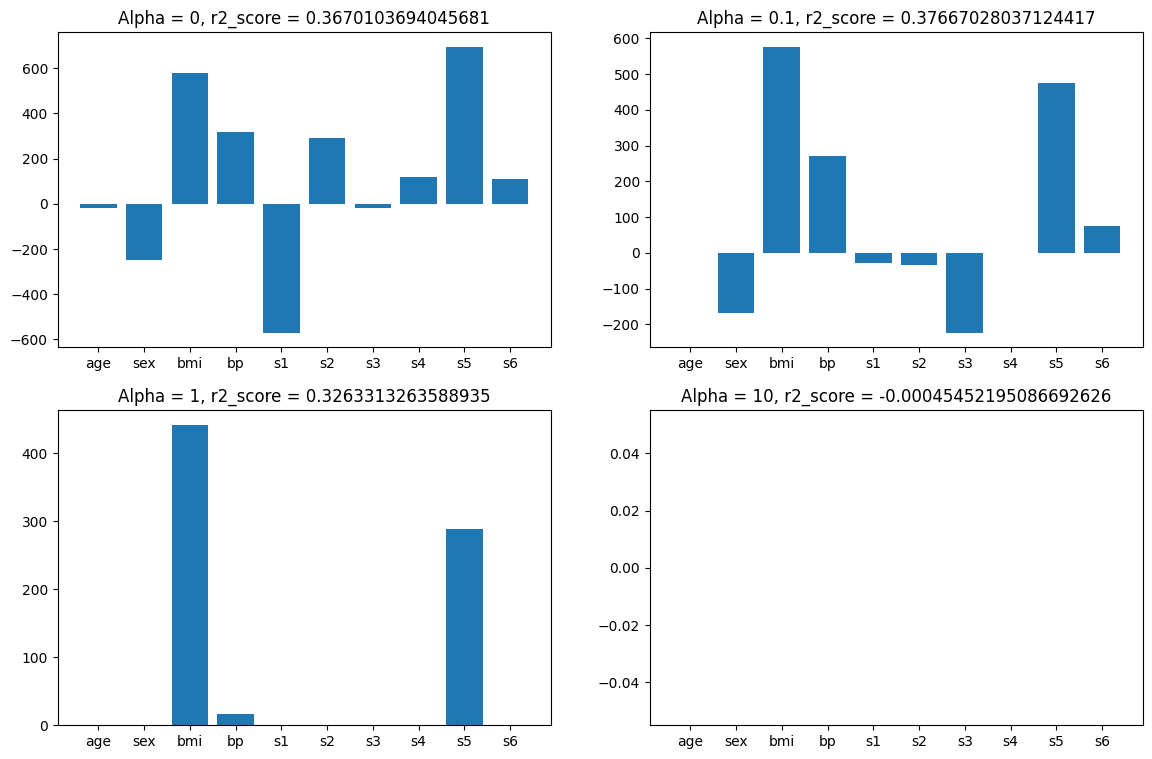

In [20]:
plt.figure(figsize = (14, 9))
plt.subplot(221)
plt.bar(data.feature_names, coef[0])
plt.title("Alpha = 0, r2_score = {}".format(r2_scores[0]))

plt.subplot(222)
plt.bar(data.feature_names, coef[1])
plt.title("Alpha = 0.1, r2_score = {}".format(r2_scores[1]))

plt.subplot(223)
plt.bar(data.feature_names, coef[2])
plt.title("Alpha = 1, r2_score = {}".format(r2_scores[2]))

plt.subplot(224)
plt.bar(data.feature_names, coef[3])
plt.title("Alpha = 10, r2_score = {}".format(r2_scores[3]))

plt.show()